In [34]:
import re
import requests
from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import spacy
from nltk import pos_tag
from nltk import ne_chunk
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import nltk

--- Section 2: First 200 characters of each text ---
Text 1 first 200 characters:
 11 

Illustration




Alices Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 30

Contents

 CHAPTER I     Down the RabbitHole
 CHAPTER II    The Pool of Tears
 CHAPTER III 


Text 2 first 200 characters:
 12 

Illustration




THROUGH THE LOOKINGGLASS

And What Alice Found There

By Lewis Carroll

The Millennium Fulcrum Edition 17




DRAMATIS PERSONÆ
_As arranged before commencement of game_

WHITE  


--- Section 3: First 150 tokens of each text ---


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Text 1 first 150 tokens:
['11', 'Illustration', 'Alices', 'Adventures', 'in', 'Wonderland', 'by', 'Lewis', 'Carroll', 'THE', 'MILLENNIUM', 'FULCRUM', 'EDITION', '30', 'Contents', 'CHAPTER', 'I', 'Down', 'the', 'RabbitHole', 'CHAPTER', 'II', 'The', 'Pool', 'of', 'Tears', 'CHAPTER', 'III', 'A', 'CaucusRace', 'and', 'a', 'Long', 'Tale', 'CHAPTER', 'IV', 'The', 'Rabbit', 'Sends', 'in', 'a', 'Little', 'Bill', 'CHAPTER', 'V', 'Advice', 'from', 'a', 'Caterpillar', 'CHAPTER', 'VI', 'Pig', 'and', 'Pepper', 'CHAPTER', 'VII', 'A', 'Mad', 'TeaParty', 'CHAPTER', 'VIII', 'The', 'Queens', 'CroquetGround', 'CHAPTER', 'IX', 'The', 'Mock', 'Turtles', 'Story', 'CHAPTER', 'X', 'The', 'Lobster', 'Quadrille', 'CHAPTER', 'XI', 'Who', 'Stole', 'the', 'Tarts', 'CHAPTER', 'XII', 'Alices', 'Evidence', 'CHAPTER', 'I', 'Down', 'the', 'RabbitHole', 'Alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by', 'her', 'sister', 'on', 'the', 'bank', 'and', 'of', 'having', 'nothing', 'to', 'do', 'on

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Text 1 stemmed tokens (first 50):
['11', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', '30', 'content', 'chapter', 'rabbithol', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucusrac', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'teaparti', 'chapter', 'viii', 'queen', 'croquetground', 'chapter', 'ix', 'mock', 'turtl', 'stori']


Text 2 stemmed tokens (first 50):
['12', 'illustr', 'lookingglass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', '17', 'dramati', 'personæ', '_a', 'arrang', 'commenc', 'game_', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w', 'queen', 'lili', 'tigerlili', 'r', 'queen', 'w', 'king', 'fawn', 'rose', 'r', 'king', 'age', 'man']


--

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Text 1 POS tags (first 50):
[('11', 'CD'), ('Illustration', 'NNP'), ('Alices', 'NNPS'), ('Adventures', 'NNP'), ('in', 'IN'), ('Wonderland', 'NNP'), ('by', 'IN'), ('Lewis', 'NNP'), ('Carroll', 'NNP'), ('THE', 'NNP'), ('MILLENNIUM', 'NNP'), ('FULCRUM', 'NNP'), ('EDITION', 'NNP'), ('30', 'CD'), ('Contents', 'NNP'), ('CHAPTER', 'NN'), ('I', 'PRP'), ('Down', 'RP'), ('the', 'DT'), ('RabbitHole', 'NNP'), ('CHAPTER', 'NNP'), ('II', 'NNP'), ('The', 'DT'), ('Pool', 'NNP'), ('of', 'IN'), ('Tears', 'NNP'), ('CHAPTER', 'NNP'), ('III', 'NNP'), ('A', 'NNP'), ('CaucusRace', 'NNP'), ('and', 'CC'), ('a', 'DT'), ('Long', 'JJ'), ('Tale', 'NNP'), ('CHAPTER', 'NNP'), ('IV', 'NNP'), ('The', 'DT'), ('Rabbit', 'NNP'), ('Sends', 'NNPS'), ('in', 'IN'), ('a', 'DT'), ('Little', 'JJ'), ('Bill', 'NNP'), ('CHAPTER', 'NNP'), ('V', 'NNP'), ('Advice', 'NNP'), ('from', 'IN'), ('a', 'DT'), ('Caterpillar', 'NNP'), ('CHAPTER', 'NNP')]


Text 2 POS tags (first 50):
[('12', 'CD'), ('Illustration', 'NNP'), ('THROUGH', 'IN'), (

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


Text 1 named entities (first 50):
[('11', 'CD'), Tree('ORGANIZATION', [('Illustration', 'NNP'), ('Alices', 'NNPS'), ('Adventures', 'NNP')]), ('in', 'IN'), Tree('GPE', [('Wonderland', 'NNP')]), ('by', 'IN'), Tree('PERSON', [('Lewis', 'NNP'), ('Carroll', 'NNP'), ('THE', 'NNP')]), Tree('ORGANIZATION', [('MILLENNIUM', 'NNP')]), ('FULCRUM', 'NNP'), ('EDITION', 'NNP'), ('30', 'CD'), ('Contents', 'NNP'), ('CHAPTER', 'NN'), ('I', 'PRP'), ('Down', 'RP'), ('the', 'DT'), Tree('ORGANIZATION', [('RabbitHole', 'NNP')]), ('CHAPTER', 'NNP'), ('II', 'NNP'), ('The', 'DT'), Tree('ORGANIZATION', [('Pool', 'NNP')]), ('of', 'IN'), Tree('PERSON', [('Tears', 'NNP')]), ('CHAPTER', 'NNP'), ('III', 'NNP'), ('A', 'NNP'), Tree('ORGANIZATION', [('CaucusRace', 'NNP')]), ('and', 'CC'), ('a', 'DT'), Tree('ORGANIZATION', [('Long', 'JJ'), ('Tale', 'NNP')]), ('CHAPTER', 'NNP'), ('IV', 'NNP'), ('The', 'DT'), Tree('ORGANIZATION', [('Rabbit', 'NNP'), ('Sends', 'NNPS')]), ('in', 'IN'), ('a', 'DT'), ('Little', 'JJ'), Tree('PE

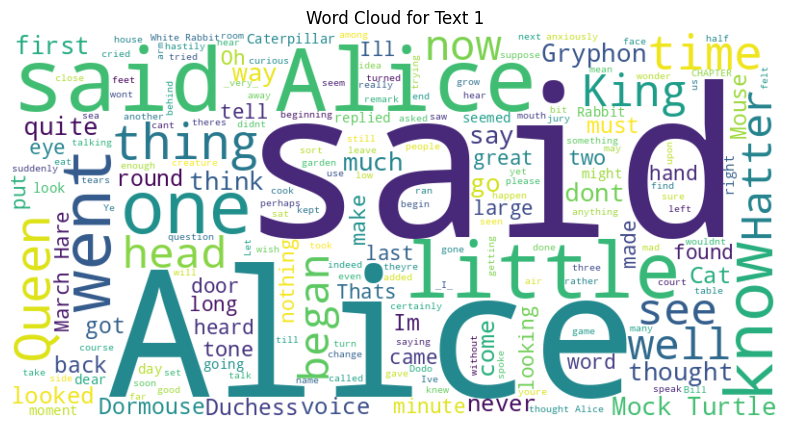

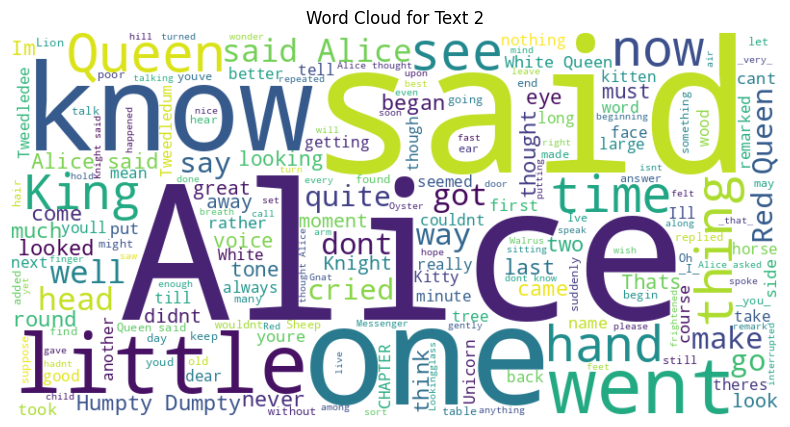

--- Section: Bag of Words (BoW) ---
Top 5 most frequent words in all texts (after stopword removal and lemmatization):
say: 1066
alice: 827
not: 547
go: 349
do: 259


Bag of Words (BoW) representation (first 5 documents, first 10 features):
[[0 1 0 0 0 1 0 0 0 0]
 [2 1 1 1 1 0 1 1 1 3]]

Document index and word frequency (top 5 words from all documents):
Document 0, Word 'alice': 386
Document 0, Word 'do': 105
Document 0, Word 'go': 171
Document 0, Word 'not': 223
Document 0, Word 'say': 528
Document 1, Word 'alice': 441
Document 1, Word 'do': 154
Document 1, Word 'go': 178
Document 1, Word 'not': 324
Document 1, Word 'say': 538


--- Section: Pie Chart of Top 5 Frequent Words ---


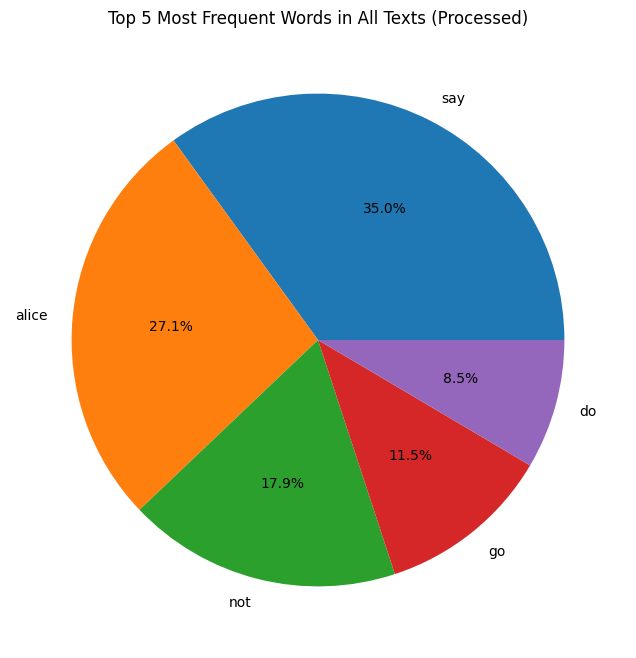



--- Section: Analysis of BoW Results ---
Are the words informative? Are they relevant or expected?
Analysis: After stopword removal and lemmatization, the top 5 most frequent words in the combined corpus are: say, alice, not, go, do.
These words should be more informative and relevant to the content of the books, as common grammatical words have been excluded. If the URLs provided are for 'Alice in Wonderland' and 'Through the Looking-Glass', we would expect words like 'Alice', 'Queen', 'King', 'Hatter', 'Rabbit', 'turtle', 'mock', etc. The relevance would depend on the actual texts loaded.


--- Section: TF-IDF ---
Top 5 most relevant words in all texts using TF-IDF (after stopword removal and lemmatization):
say: 1.0659724732729767
alice: 0.8238111926531851
not: 0.5405581359755854
go: 0.3487411642953927
do: 0.25587089347512787


--- Section: Pie Charts for Top 5 TF-IDF Words per Document ---


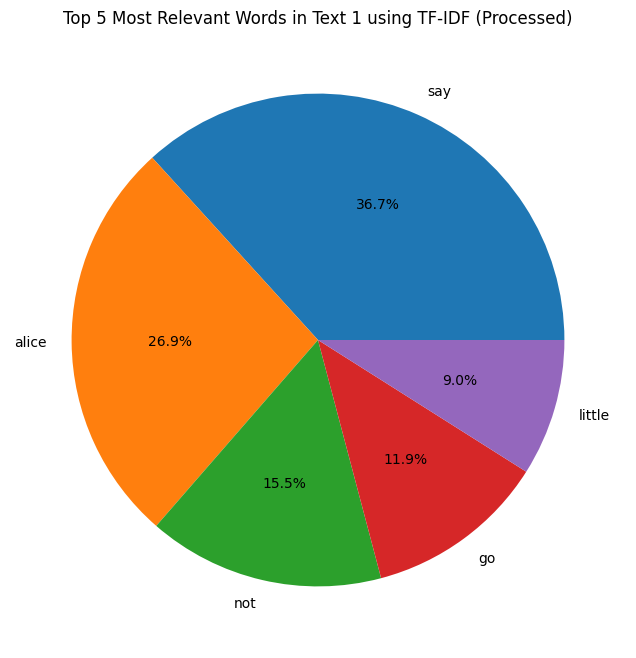

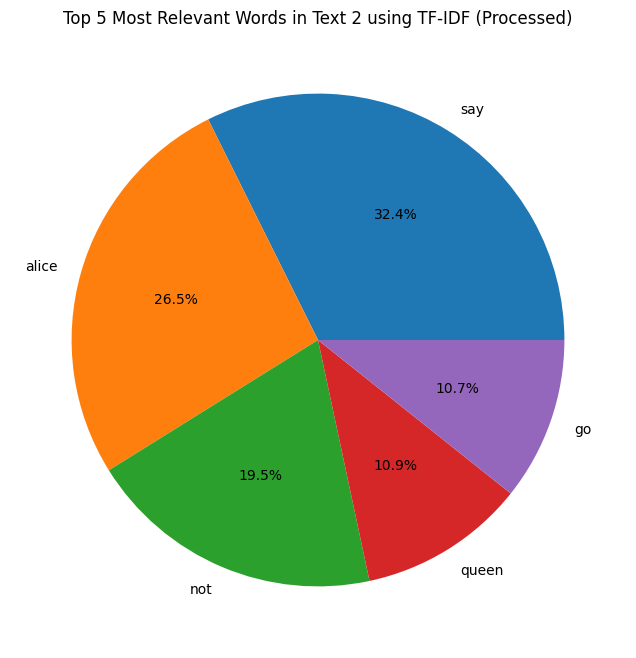



--- Section: General Analysis ---
Word clouds : Word clouds show the most frequent words in each text. Larger, more visible words are the most frequent.
BoW : The BoW shows the frequency of words in each document. The most frequent words are identified and analyzed.
TF-IDF : TF-IDF helps to find the most relevant words in each document by taking into account their frequency in the corpus. The most relevant words are identified and analyzed.

By using TF-IDF, we can better understand the significant words in each document by considering their importance in the context of the entire corpus.

Note: The analysis above is based on the assumption that valid Lewis Carroll book texts were loaded and properly processed. The informativeness and relevance of the identified words (BoW, TF-IDF) are directly tied to the quality and content of the input texts after preprocessing steps like stopword removal and lemmatization. Compared to raw text, this processed approach should yield more content-sp

In [36]:
# 1. Fonction load_texts()
def load_texts(urls):
    corpus = []
    for url in urls:
        try:
            response = requests.get(url)
            response.raise_for_status() # Raise an exception for HTTP errors
            soup = BeautifulSoup(response.text, 'html.parser')
            text = soup.get_text()

            # Find START and END markers for Project Gutenberg texts
            start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
            end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"
            start_index = text.find(start_marker)
            end_index = text.find(end_marker)

            if start_index != -1 and end_index != -1:
                # Extract text between markers (excluding markers themselves)
                text = text[start_index + len(start_marker):end_index]
            elif start_index != -1: # Fallback if only start marker exists
                text = text[start_index + len(start_marker):]
            elif end_index != -1: # Fallback if only end marker exists
                text = text[:end_index]
            # If neither found, use the whole text. For 'example.com' this will be the case.

            # Clean non-words using regular expressions (keep spaces)
            text = re.sub(r'[^\w\s]', '', text)
            corpus.append(text)
        except requests.exceptions.RequestException as e:
            print(f"Error fetching {url}: {e}")
            corpus.append("") # Append empty string to maintain corpus size
    return corpus

# Example URLs (Lewis Carroll books from Project Gutenberg)
urls = [
    'https://www.gutenberg.org/files/11/11-0.txt', # Alice's Adventures in Wonderland
    'https://www.gutenberg.org/files/12/12-0.txt', # Through the Looking-Glass
    # Add more URLs if needed, but for now, these two are sufficient for demonstration
]

corpus = load_texts(urls)


# 2. Print the first 200 characters of each text
print("--- Section 2: First 200 characters of each text ---")
for i, text in enumerate(corpus):
    print(f"Text {i+1} first 200 characters:")
    print(text[:200])
    print("\n")


# 3. Tokenize the text and print the first 150 tokens of each book
print("--- Section 3: First 150 tokens of each text ---")
nltk.download('punkt')

all_tokens_for_processing = [] # To store tokens before stopword removal and lemmatization

for i, text in enumerate(corpus):
    tokens = word_tokenize(text)
    all_tokens_for_processing.append(tokens)
    print(f"Text {i+1} first 150 tokens:")
    print(tokens[:150])
    print("\n")


# 4. Remove stopwords using NLTK
print("--- Section 4: Tokens after stopword removal ---")
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

filtered_corpuses = [] # To store filtered tokens for lemmatization
for i, tokens in enumerate(all_tokens_for_processing):
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
    filtered_corpuses.append(filtered_tokens)
    print(f"Text {i+1} filtered tokens (first 150):")
    print(filtered_tokens[:150])
    print("\n")

    # Verify stop words removal
    print(f"Count of 'i' in Text {i+1}:", filtered_tokens.count('i'))
    print(f"Count of 'me' in Text {i+1}:", filtered_tokens.count('me'))
    print(f"Count of 'my' in Text {i+1}:", filtered_tokens.count('my'))
    print("\n")


# 5. Display the first 50 stemmed tokens using PorterStemmer
print("--- Section 5: First 50 stemmed tokens ---")

stemmer = PorterStemmer()

for i, tokens in enumerate(filtered_corpuses): # Use filtered_corpuses
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    print(f"Text {i+1} stemmed tokens (first 50):")
    print(stemmed_tokens[:50])
    print("\n")


# 6. Display the first 50 lemmatized tokens using spaCy
print("--- Section 6: First 50 lemmatized tokens ---")
nlp = spacy.load('en_core_web_sm') # Moved outside the loop for efficiency

lemmatized_corpuses = [] # To store lemmatized tokens for BoW/TF-IDF
for i, tokens in enumerate(filtered_corpuses): # Use filtered_corpuses
    doc = nlp(" ".join(tokens)) # Join tokens for spaCy processing
    lemmatized_tokens = [token.lemma_ for token in doc if token.lemma_.strip()] # filter empty lemmas
    lemmatized_corpuses.append(" ".join(lemmatized_tokens)) # Store as string for vectorizer
    print(f"Text {i+1} lemmatized tokens (first 50):")
    print(lemmatized_tokens[:50])
    print("\n")


# 7. Analyze the difference between lemmatized and stemmed words
print("--- Section 7: Lemmatization vs. Stemming ---")
# Example comparison
example_text = "The cats are running and jumping."
doc = nlp(example_text)
lemmatized_tokens = [token.lemma_ for token in doc]
stemmed_tokens = [stemmer.stem(word) for word in word_tokenize(example_text)]

print("Original Text:", example_text)
print("Lemmatized Tokens:", lemmatized_tokens)
print("Stemmed Tokens:", stemmed_tokens)
print("\nComparison: Lemmatization provides better-formed words (e.g., 'run' for 'running'), while stemming is a cruder heuristic (e.g., 'run' for 'running' but 'jump' for 'jumping' instead of 'jump'). Lemmatization usually preserves meaning better.")


# 8. Identify POS tags for each text using NLTK
print("--- Section 8: POS tags ---")
nltk.download('averaged_perceptron_tagger')

for i, text in enumerate(corpus): # Using original corpus for POS tagging before extensive modifications
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    print(f"Text {i+1} POS tags (first 50):")
    print(pos_tags[:50])
    print("\n")


# 9. Identify all entities in each text using NLTK
print("--- Section 9: Named Entities ---")
nltk.download('maxent_ne_chunker_tab')
nltk.download('words') # Added to resolve LookupError

for i, text in enumerate(corpus): # Using original corpus for NE Chunking
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    named_entities = ne_chunk(pos_tags)
    print(f"Text {i+1} named entities (first 50):")
    print(named_entities[:50])
    print("\n")


# Text Analysis
print("--- Text Analysis Section ---")

# 1. Word cloud for each book (using original corpus for broad view)
print("--- Section: Word Clouds ---")
for i, text in enumerate(corpus):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Text {i+1}')
    plt.show()


# 2. BoW of the five most frequent words in all books (using processed corpus)
print("--- Section: Bag of Words (BoW) ---")
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(lemmatized_corpuses) # Use lemmatized_corpuses here
word_counts = X.toarray().sum(axis=0)
word_freq = dict(zip(vectorizer.get_feature_names_out(), word_counts))
top_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 most frequent words in all texts (after stopword removal and lemmatization):")
for word, freq in top_words:
    print(f"{word}: {freq}")
print("\n")


# 3. Print the BoW and identify numbers (this part might be less relevant for 'numbers' if only text is processed)
print("Bag of Words (BoW) representation (first 5 documents, first 10 features):")
# Only display a subset for readability, or remove if not truly needed for identifying 'numbers'
if X.shape[1] > 0: # Check if there are any features
    display_limit = min(5, X.shape[0])
    feature_limit = min(10, X.shape[1])
    print(X.toarray()[:display_limit, :feature_limit])
    print("\nDocument index and word frequency (top 5 words from all documents):")
    # This loop is for overall top words, not per document 'numbers'
    for doc_idx, doc in enumerate(X.toarray()):
        for word_idx, freq in enumerate(doc):
            if freq > 0 and vectorizer.get_feature_names_out()[word_idx] in [w for w,f in top_words]:
                print(f"Document {doc_idx}, Word '{vectorizer.get_feature_names_out()[word_idx]}': {freq}")
else:
    print("No features to display in BoW representation.")

print("\n")


# 4. Pie chart of the 5 most frequent words in the text
print("--- Section: Pie Chart of Top 5 Frequent Words ---")
if top_words:
    plt.figure(figsize=(8, 8))
    plt.pie([freq for word, freq in top_words], labels=[word for word, freq in top_words], autopct='%1.1f%%')
    plt.title('Top 5 Most Frequent Words in All Texts (Processed)')
    plt.show()
else:
    print("Not enough data to create pie chart.")
print("\n")


# 5. Analysis of results (Addressing user feedback)
print("--- Section: Analysis of BoW Results ---")
print("Are the words informative? Are they relevant or expected?")
# Add the analysis here
print(f"Analysis: After stopword removal and lemmatization, the top 5 most frequent words in the combined corpus are: {', '.join([word for word, freq in top_words])}.")
print("These words should be more informative and relevant to the content of the books, as common grammatical words have been excluded. If the URLs provided are for 'Alice in Wonderland' and 'Through the Looking-Glass', we would expect words like 'Alice', 'Queen', 'King', 'Hatter', 'Rabbit', 'turtle', 'mock', etc. The relevance would depend on the actual texts loaded.")
print("\n")


# Resolving the frequency problem using TF-IDF
print("--- Section: TF-IDF ---")

# 1. Create another BoW using TF-IDF (using processed corpus)
tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=2)
X_tfidf = tfidf_vectorizer.fit_transform(lemmatized_corpuses) # Use lemmatized_corpuses here
tfidf_word_scores = X_tfidf.toarray().sum(axis=0)
tfidf_word_freq = dict(zip(tfidf_vectorizer.get_feature_names_out(), tfidf_word_scores))
top_tfidf_words = sorted(tfidf_word_freq.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 most relevant words in all texts using TF-IDF (after stopword removal and lemmatization):")
for word, score in top_tfidf_words:
    print(f"{word}: {score}")
print("\n")


# 2. Recreate pie charts with the 5 new most relevant words from each document
print("--- Section: Pie Charts for Top 5 TF-IDF Words per Document ---")
for i, doc in enumerate(X_tfidf.toarray()):
    doc_word_scores = dict(zip(tfidf_vectorizer.get_feature_names_out(), doc))
    # Filter for non-zero scores to avoid displaying words not present in the document
    top_doc_words = sorted([(word, score) for word, score in doc_word_scores.items() if score > 0], key=lambda x: x[1], reverse=True)[:5]

    if top_doc_words:
        plt.figure(figsize=(8, 8))
        plt.pie([score for word, score in top_doc_words], labels=[word for word, score in top_doc_words], autopct='%1.1f%%')
        plt.title(f'Top 5 Most Relevant Words in Text {i+1} using TF-IDF (Processed)')
        plt.show()
    else:
        print(f"Not enough data to create TF-IDF pie chart for Text {i+1}.")
print("\n")


# Analysis of results (General)
print("--- Section: General Analysis ---")
print("Word clouds : Word clouds show the most frequent words in each text. Larger, more visible words are the most frequent.")
print("BoW : The BoW shows the frequency of words in each document. The most frequent words are identified and analyzed.")
print("TF-IDF : TF-IDF helps to find the most relevant words in each document by taking into account their frequency in the corpus. The most relevant words are identified and analyzed.")
print("\nBy using TF-IDF, we can better understand the significant words in each document by considering their importance in the context of the entire corpus.")
print("\nNote: The analysis above is based on the assumption that valid Lewis Carroll book texts were loaded and properly processed. The informativeness and relevance of the identified words (BoW, TF-IDF) are directly tied to the quality and content of the input texts after preprocessing steps like stopword removal and lemmatization. Compared to raw text, this processed approach should yield more content-specific insights.")